In [1]:
from data_processing import (
    prepare_imbalanced_fake_news_data,
    prepare_imbalanced_real_news_data,
)

In [2]:
train_df, test_df = prepare_imbalanced_real_news_data(
    "data/real-news.txt", "data/fake-news.txt"
)

In [3]:
train_df["is_real"].value_counts()

is_real
1    7318
0    3658
Name: count, dtype: int64

In [4]:
test_df["is_real"].value_counts()

is_real
1    1829
0     915
Name: count, dtype: int64

In [5]:
from graphic import plot_classification_report
from ml_utils import train_and_evaluate

Cross-validation scores (5-fold): [0.75045537 0.74123007 0.7571754  0.75535308 0.73849658]
Mean CV accuracy: 0.7485
CV Standard deviation: 0.0075


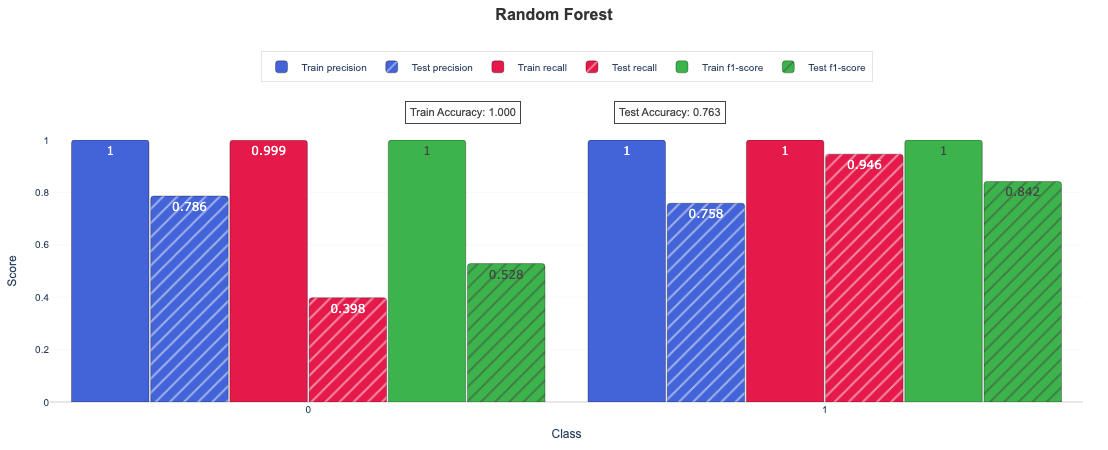

In [6]:
rf_fig_learning, rf_fig_roc, rf_train_report, rf_test_report = train_and_evaluate(
    train_df, test_df, "rf"
)  # Random Forest
plot_classification_report("Random Forest", rf_train_report, rf_test_report)

Cross-validation scores (5-fold): [0.70173042 0.69794989 0.69703872 0.70432802 0.70068337]
Mean CV accuracy: 0.7003
CV Standard deviation: 0.0026


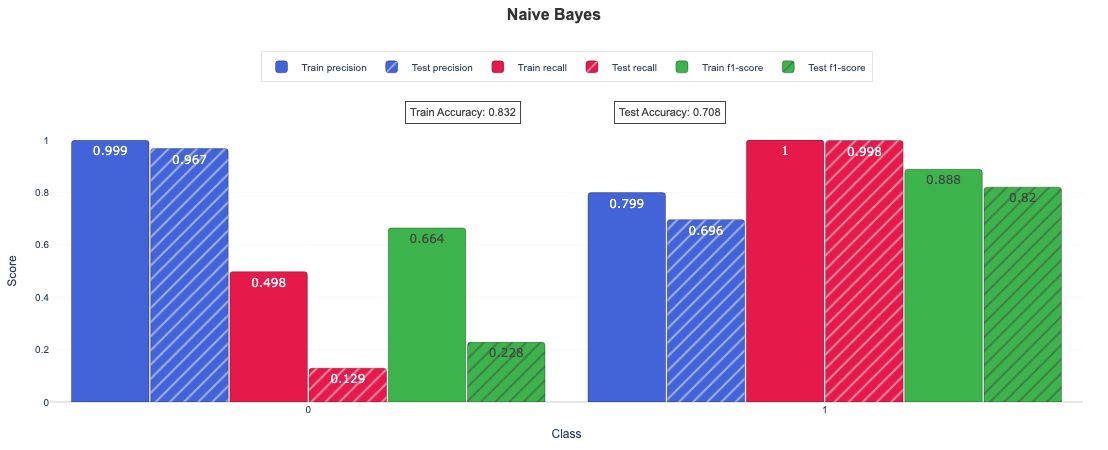

In [7]:
nb_fig_learning, nb_fig_roc, nb_train_report, nb_test_report = train_and_evaluate(
    train_df, test_df, "nb"
)  # Naive Bayes
plot_classification_report("Naive Bayes", nb_train_report, nb_test_report)

Cross-validation scores (5-fold): [0.75591985 0.7498861  0.76765376 0.75626424 0.74578588]
Mean CV accuracy: 0.7551
CV Standard deviation: 0.0074


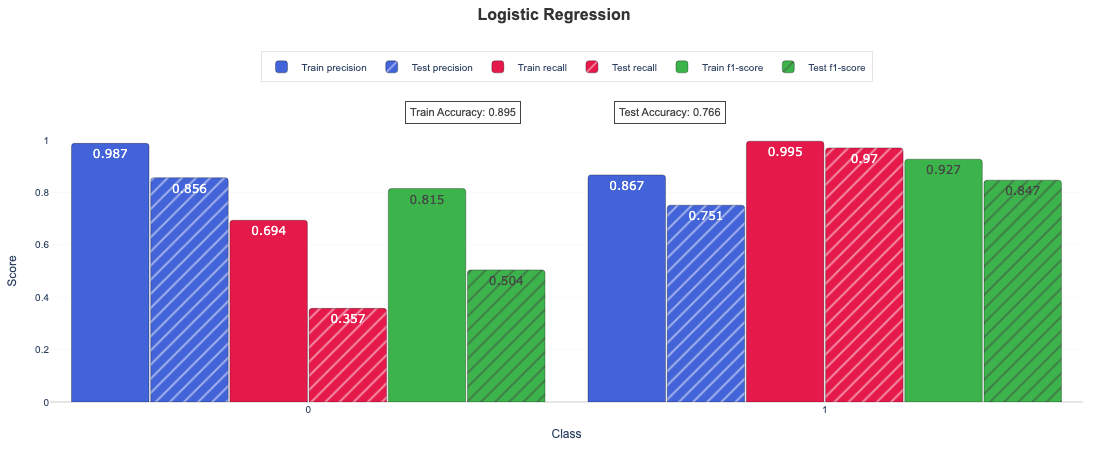

In [8]:
lr_fig_learning, lr_fig_roc, lr_train_report, lr_test_report = train_and_evaluate(
    train_df, test_df, "lr"
)  # Logistic Regression
plot_classification_report("Logistic Regression", lr_train_report, lr_test_report)

Cross-validation scores (5-fold): [0.79189435 0.78041002 0.79863326 0.79681093 0.78268793]
Mean CV accuracy: 0.7901
CV Standard deviation: 0.0073


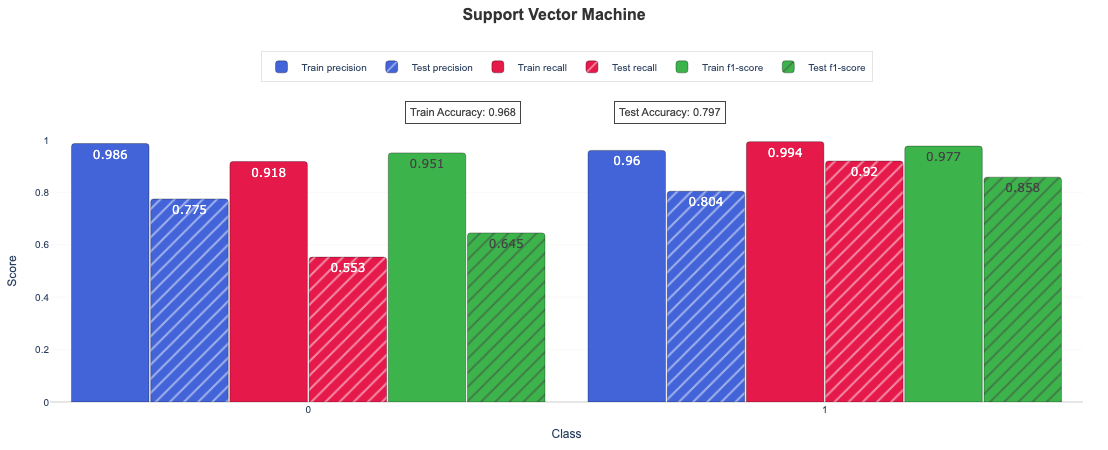

In [9]:
svm_fig_learning, svm_fig_roc, svm_train_report, svm_test_report = train_and_evaluate(
    train_df, test_df, "svm"
)  # Support Vector Machine
plot_classification_report("Support Vector Machine", svm_train_report, svm_test_report)

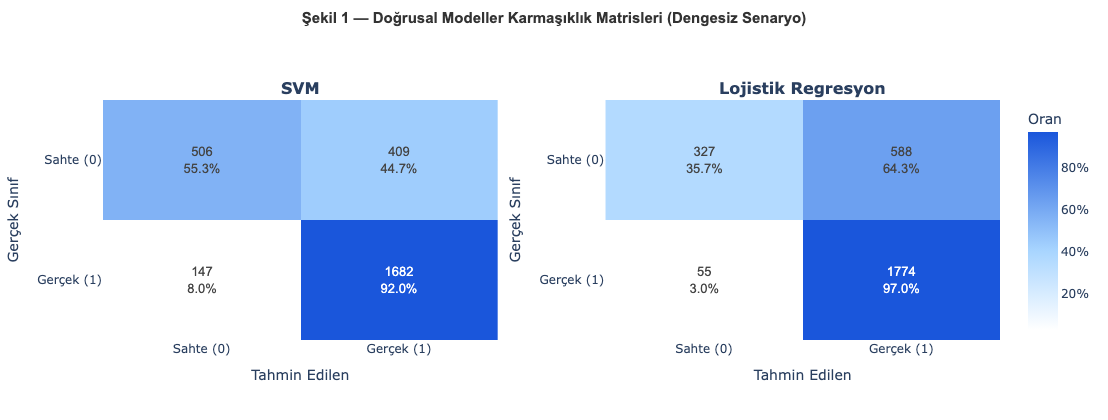

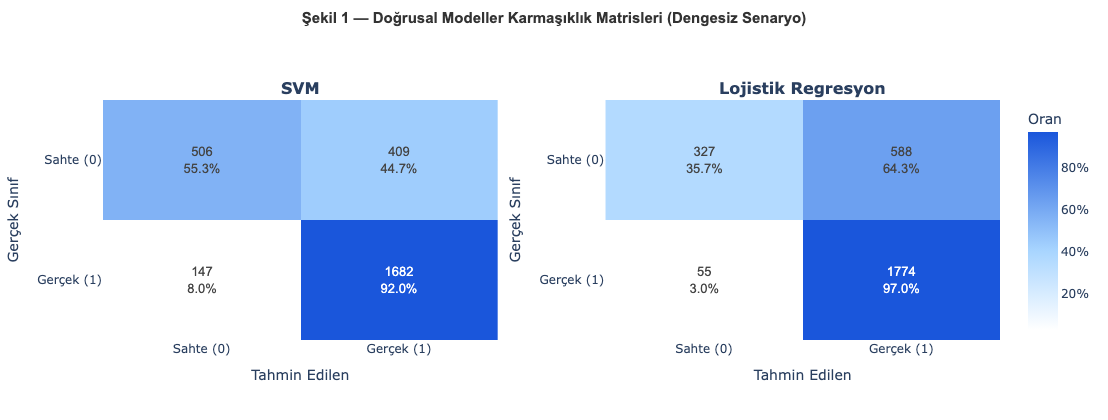

In [10]:

# Şekil 1 — SVM ve LR Karmaşıklık Matrisleri (Dengesiz Senaryo)
from graphic import plot_dual_confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

svm_pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", SVC(kernel="linear", probability=True, random_state=42))])
svm_pipe.fit(train_df["text"], train_df["is_real"])
svm_preds = svm_pipe.predict(test_df["text"])

lr_pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(l1_ratio=0, random_state=42))])
lr_pipe.fit(train_df["text"], train_df["is_real"])
lr_preds = lr_pipe.predict(test_df["text"])

plot_dual_confusion_matrix(
    "Şekil 1 — Doğrusal Modeller Karmaşıklık Matrisleri (Dengesiz Senaryo)",
    test_df["is_real"], svm_preds, "SVM",
    test_df["is_real"], lr_preds, "Lojistik Regresyon",
)
